<a href="https://colab.research.google.com/github/abhishekpandit1130/Machine-Learning-Course/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Setup & Imports

In [3]:
# Imports and basic setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

np.random.seed(42)  # for reproducibility


Step 2 — Create a Simple Dataset

In [4]:
# Create synthetic dataset (size vs price)
m = 80  # number of samples
sizes = np.random.uniform(500, 3500, size=m)       # in sq ft
true_price = 0.1 * sizes                            # noiseless relation in lakhs
noise = np.random.normal(0, 10, size=m)             # add some noise (±10 lakhs)
prices = true_price + noise

# Reshape feature for sklearn
X = sizes.reshape(-1, 1)
y = prices
print(f"Samples: {len(y)} | Size range: {sizes.min():.0f}-{sizes.max():.0f} sq ft")



Samples: 80 | Size range: 517-3461 sq ft


Step 3 — Visualize the Data

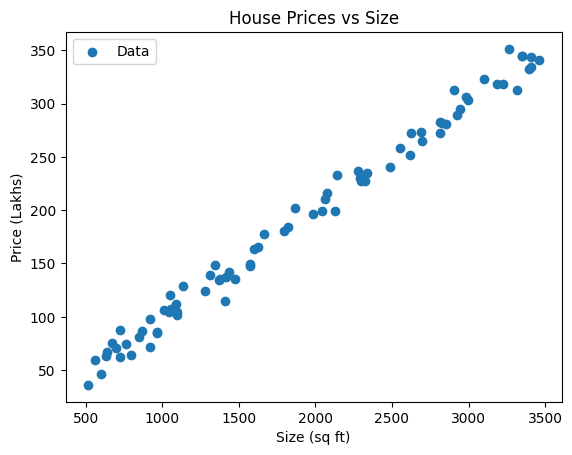

In [5]:
# Scatter plot of data

plt.figure()
plt.scatter(sizes, prices, label="Data")
plt.xlabel("Size (sq ft)")
plt.ylabel("Price (Lakhs)")
plt.title("House Prices vs Size")
plt.legend()
plt.show()


Step 4 — Baseline with Scikit-Learn

Slope (lakhs per sq ft): 0.10150
Intercept (lakhs): -2.94
R² (baseline): 0.9896


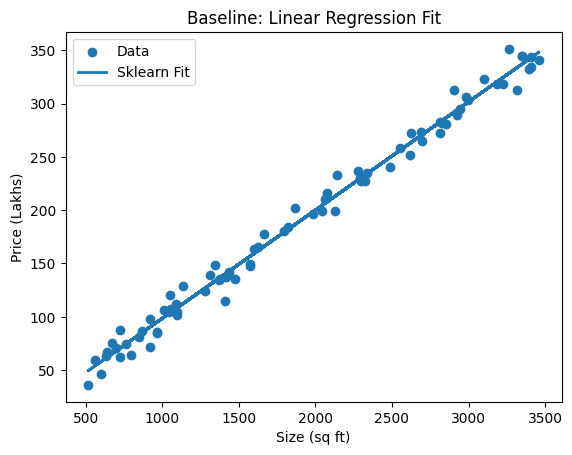

In [6]:
# Fit LinearRegression

linreg = LinearRegression()
linreg.fit(X, y)
y_pred_lr = linreg.predict(X)

print(f"Slope (lakhs per sq ft): {linreg.coef_[0]:.5f}")
print(f"Intercept (lakhs): {linreg.intercept_:.2f}")
print(f"R² (baseline): {r2_score(y, y_pred_lr):.4f}")

# Plot with regression line
plt.figure()
plt.scatter(sizes, prices, label="Data")
plt.plot(sizes, y_pred_lr, linewidth=2, label="Sklearn Fit")
plt.xlabel("Size (sq ft)")
plt.ylabel("Price (Lakhs)")
plt.title("Baseline: Linear Regression Fit")
plt.legend()
plt.show()


Step 5 — Prepare for Gradient Descent

In [7]:
# Build design matrix with bias; scale feature for stable GD

size_k = sizes / 1000.0  # scale to thousands of sq ft
X_bias = np.c_[np.ones_like(size_k), size_k]  # [1, x] for bias + weight
y_vec = y.reshape(-1, 1)

print("X_bias shape:", X_bias.shape, "| y shape:", y_vec.shape)


X_bias shape: (80, 2) | y shape: (80, 1)


Step 6 — Define Loss and Gradient Functions

In [8]:
#Loss (MSE), predict, and gradient functions

def predict(W, Xb):
    return Xb @ W  # linear model

def mse(y_true, y_hat):
    return np.mean((y_true - y_hat)**2)

def grad_mse(W, Xb, y_true):
    m = len(y_true)
    return (2/m) * (Xb.T @ (Xb @ W - y_true))

Step 7 — Train with Gradient Descent

In [9]:
# Gradient Descent training loop

epochs = 300
lr = 0.05  # learning rate (works well because we scaled x)

W = np.zeros((2, 1))  # [bias, weight] initial
r2_history = []
mse_history = []

for epoch in range(1, epochs + 1):
    y_hat = predict(W, X_bias)
    # Record metrics
    mse_history.append(mse(y_vec, y_hat))
    r2_history.append(r2_score(y_vec, y_hat) * 100.0)  # "accuracy" as R²%

    # Update
    g = grad_mse(W, X_bias, y_vec)
    W -= lr * g

print("Learned weights (GD):")
print(f"  Bias (lakhs): {W[0,0]:.3f}")
print(f"  Weight per 1000 sq ft (lakhs): {W[1,0]:.3f}")

Learned weights (GD):
  Bias (lakhs): -2.595
  Weight per 1000 sq ft (lakhs): 101.346


Step 8 — Plot Epoch vs Accuracy (R²)

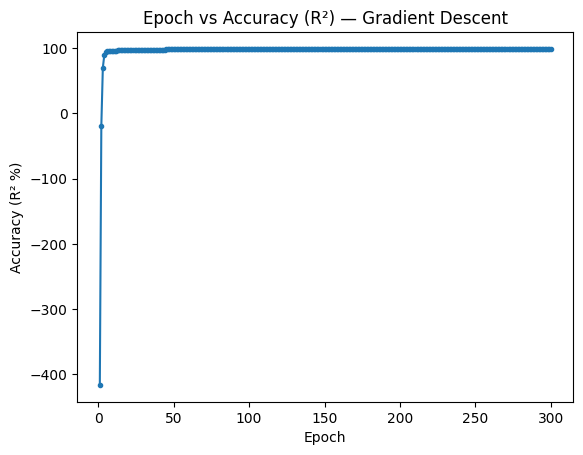

In [10]:
# Epoch vs Accuracy (R² %)

plt.figure()
plt.plot(range(1, epochs+1), r2_history, marker='.')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (R² %)")
plt.title("Epoch vs Accuracy (R²) — Gradient Descent")
plt.show()

Step 9 — Plot Epoch vs Loss (MSE)

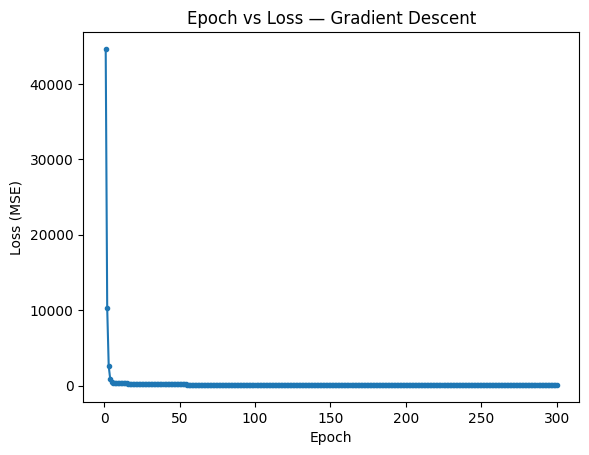

In [11]:
# Epoch vs Loss (MSE)

plt.figure()
plt.plot(range(1, epochs+1), mse_history, marker='.')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Epoch vs Loss — Gradient Descent")
plt.show()

Step 10 — Compare GD Fit with Sklearn Fit

GD intercept (lakhs): -2.595
GD slope (lakhs per sq ft): 0.10135


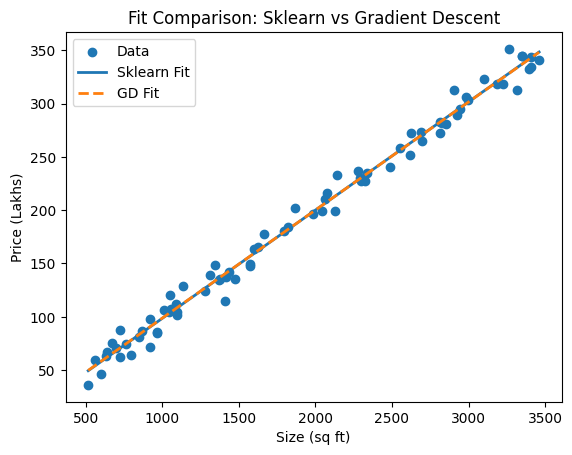

In [12]:
# Compare predictions from GD vs Sklearn
# Convert GD weights back to "per sq ft" slope for comparison:
# price ≈ W0 + W1 * (size/1000)  => slope_per_sqft = W1 / 1000

gd_intercept = W[0,0]
gd_slope_per_sqft = W[1,0] / 1000.0

print(f"GD intercept (lakhs): {gd_intercept:.3f}")
print(f"GD slope (lakhs per sq ft): {gd_slope_per_sqft:.5f}")

# Plot both lines
sizes_sorted = np.sort(sizes)
X_sorted = sizes_sorted.reshape(-1, 1)
y_pred_lr_sorted = linreg.predict(X_sorted)
y_pred_gd_sorted = gd_intercept + gd_slope_per_sqft * sizes_sorted

plt.figure()
plt.scatter(sizes, prices, label="Data")
plt.plot(sizes_sorted, y_pred_lr_sorted, linewidth=2, label="Sklearn Fit")
plt.plot(sizes_sorted, y_pred_gd_sorted, linewidth=2, linestyle='--', label="GD Fit")
plt.xlabel("Size (sq ft)")
plt.ylabel("Price (Lakhs)")
plt.title("Fit Comparison: Sklearn vs Gradient Descent")
plt.legend()
plt.show()


Step 11 — Predict New House Prices

In [13]:
# Helper to predict price for a given size using GD weights
def predict_price_gd(size_sqft):
    return float(gd_intercept + gd_slope_per_sqft * size_sqft)

test_sizes = [800, 1200, 2000, 3000]
for s in test_sizes:
    print(f"Size {s} sq ft -> Predicted Price: {predict_price_gd(s):.2f} lakhs")


Size 800 sq ft -> Predicted Price: 78.48 lakhs
Size 1200 sq ft -> Predicted Price: 119.02 lakhs
Size 2000 sq ft -> Predicted Price: 200.10 lakhs
Size 3000 sq ft -> Predicted Price: 301.44 lakhs
